# Imputacion de Datos Faltantes

- Metodo `MICE`

1. Tipos de datos faltantes
2. ¿Que tipos de datos pueden ser imputados con MICE?
3. El algoritmo MICE para variables numericas
4. Ejemplo practico

## 1. Tipos de datos faltantes

### 1.1 Datos faltantes completamente aleatorio (MCAR: missing completely at random)
 
 > La razon que explica los datos faltantes es totalmente independiente de las variables del dataset o de los valores mismos de la variable que esta incompleta 

 ![](../img/estadistica/ejemplo_MCAR.png)



### 1.2 Datos faltante NO aleatorios (MNAR: missing not a random)

![](../img/estadistica/ejemplo_MNAR.png)

### 1.3 Datos faltantes aleatorios (MNAR: missing at random)

![](../img/estadistica/ejemplo_MAR.png)

## 2. MICE (Multiple Imputation by Chained Equations)

- Variables numericas (edad, ingresos, temperatura, etc)
- Variables categoricas (genero, nivel educacion, etc)
- Cuando el motivo detras de los datos faltantes es MAR, MCAR

## 3. El algoritmo MICE para variables numericas

![](../img/estadistica/imputacion_MICE.png)

## 4. Ejemplo practico

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/dataset_numerico_MAR.csv')
df

,Edad,Ingresos,Experiencia
0,58.0,32433.0,3.0
1,48.0,35311.0,NaN
2,NaN,67819.0,NaN
3,27.0,69188.0,7.0
4,40.0,47568.0,9.0
5,NaN,49769.0,7.0
6,38.0,NaN,18.0
7,42.0,36396.0,4.0
8,30.0,57480.0,14.0
9,30.0,NaN,18.0


In [2]:
df.isna().sum()

Edad           4
Ingresos       4
Experiencia    4
dtype: int64

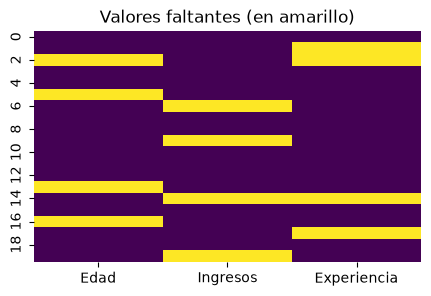

In [3]:
plt.figure(figsize=(5, 3))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Valores faltantes (en amarillo)")
plt.show()

Podemos usar `IterativeImputer` de Scikit-Learn que implementa el algotirmo MICE para variables numericas

In [4]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

A continuacion creamos una instancia de `InterativeImputer`

In [5]:
imputador = IterativeImputer(max_iter=20, random_state=123)

Donde:

- `max_iter` es el numero maximo de iteraciones
- `random_state` es la semilla del generador aleatorio que fijamos para la reproducibilidad de los resultados

Veamos algunos parametros del imputador:

In [6]:
imputador.get_params()

{'add_indicator': False,
 'estimator': None,
 'fill_value': None,
 'imputation_order': 'ascending',
 'initial_strategy': 'mean',
 'keep_empty_features': False,
 'max_iter': 20,
 'max_value': inf,
 'min_value': -inf,
 'missing_values': nan,
 'n_nearest_features': None,
 'random_state': 123,
 'sample_posterior': False,
 'skip_complete': False,
 'tol': 0.001,
 'verbose': 0}

Ahora simplemente debemos ejecutar el algotirmo para realizar la imputacion. En este caso usamos `fit_transform()`

In [7]:
imputaciones = imputador.fit_transform(df)
imputaciones

array([[5.80000000e+01, 3.24330000e+04, 3.00000000e+00],
       [4.80000000e+01, 3.53110000e+04, 8.69218302e+00],
       [2.91622949e+01, 6.78190000e+04, 1.29620591e+01],
       [2.70000000e+01, 6.91880000e+04, 7.00000000e+00],
       [4.00000000e+01, 4.75680000e+04, 9.00000000e+00],
       [4.11972135e+01, 4.97690000e+04, 7.00000000e+00],
       [3.80000000e+01, 5.40218514e+04, 1.80000000e+01],
       [4.20000000e+01, 3.63960000e+04, 4.00000000e+00],
       [3.00000000e+01, 5.74800000e+04, 1.40000000e+01],
       [3.00000000e+01, 6.05573032e+04, 1.80000000e+01],
       [4.30000000e+01, 5.56580000e+04, 9.00000000e+00],
       [5.50000000e+01, 4.89420000e+04, 2.00000000e+00],
       [5.90000000e+01, 4.84310000e+04, 1.50000000e+01],
       [5.25467016e+01, 3.27470000e+04, 7.00000000e+00],
       [2.20000000e+01, 6.56561916e+04, 1.26779958e+01],
       [4.10000000e+01, 4.91180000e+04, 8.00000000e+00],
       [3.05264713e+01, 6.57730000e+04, 1.50000000e+01],
       [4.30000000e+01, 3.18990

In [8]:
type(imputaciones)

numpy.ndarray

Lo anterior esta en formato de arreglo de Numpy. asi que resulta mas facil de interpretar si lo ponemos en formato DataFrame

In [9]:
df_imputado = pd.DataFrame(imputaciones, columns=df.columns)
df_imputado

,Edad,Ingresos,Experiencia
0,58.000000,32433.000000,3.000000
1,48.000000,35311.000000,8.692183
2,29.162295,67819.000000,12.962059
3,27.000000,69188.000000,7.000000
4,40.000000,47568.000000,9.000000
5,41.197213,49769.000000,7.000000
6,38.000000,54021.851371,18.000000
7,42.000000,36396.000000,4.000000
8,30.000000,57480.000000,14.000000
9,30.000000,60557.303219,18.000000
